In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data_complete.csv')

In [3]:
df.head()

,timestamp,floor_id,hvac_zone,current_co2,current_temperature,current_humidity,floor,corner,ahu_id,FCU_1,...,AHU_OBDM,AHU_RDT,AHU_RUN,AHU_SDT,AHU_TMSET,CHU_SS,CHU_TMSET,temperature_out,humidity_out,solar_radiation
0,4/3/2025 14:15,7F,7F_SouthWest,805.0,25.7,26.0,7F,SouthWest,AHU5,inactive,...,0.0,21.643126,inactive,22.143168,22.0,inactive,28.0,14.525,38.5,653.05
1,4/3/2025 14:15,9F,9F_SouthWest,580.0,28.2,23.0,9F,SouthWest,AHU5,inactive,...,0.0,21.643126,inactive,22.143168,22.0,inactive,28.0,14.525,38.5,653.05
2,4/3/2025 14:15,3F,3F_NorthWest,503.0,22.3,29.5,3F,NorthWest,AHU4,inactive,...,0.0,18.502874,inactive,20.663050,22.0,inactive,28.0,14.525,38.5,653.05
3,4/3/2025 14:15,8F,8F_SouthWest,745.0,27.5,23.5,8F,SouthWest,AHU5,inactive,...,0.0,21.643126,inactive,22.143168,22.0,inactive,28.0,14.525,38.5,653.05
4,4/3/2025 14:15,3F,3F_NorthEast,605.0,23.3,28.0,3F,NorthEast,AHU3,inactive,...,0.0,18.802900,inactive,20.062998,22.0,inactive,28.0,14.525,38.5,653.05


In [4]:
df.columns

Index(['timestamp', 'floor_id', 'hvac_zone', 'current_co2',
       'current_temperature', 'current_humidity', 'floor', 'corner', 'ahu_id',
       'FCU_1', 'FCU_2', 'FCU_3', 'FCU_4', 'FCU_5', 'FCU_6', 'FCU_7', 'FCU_8',
       'FCU_9', 'FCU_10', 'FCU_11', 'AHU_MDM', 'AHU_MDT', 'AHU_MODE',
       'AHU_OBDM', 'AHU_RDT', 'AHU_RUN', 'AHU_SDT', 'AHU_TMSET', 'CHU_SS',
       'CHU_TMSET', 'temperature_out', 'humidity_out', 'solar_radiation'],
      dtype='object')

In [5]:
ahu6 = df[df['ahu_id'] == 'AHU6']

In [ ]:
# groupp by time stamp and averange values
temps = ahu6[['timestamp','AHU_RDT','AHU_SDT']].groupby('timestamp').mean().reset_index()

# same plot but interactive
import plotly.express as px
fig = px.line(temps, x='timestamp', y=['AHU_RDT', 'AHU_SDT'], labels={
    'value': 'Temperature (°C)',
    'timestamp': 'Timestamp',
    'variable': 'Temperature Type'
}, title='AHU6 Return and Supply Duct Temperatures Over Time')
fig.show()

: 

# normalization

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\2095827128.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



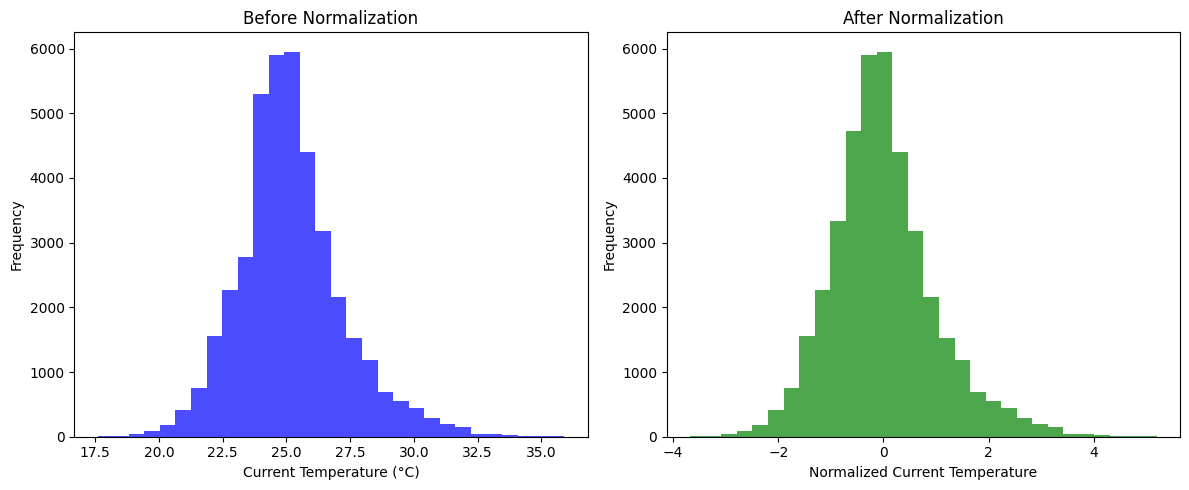

In [8]:
# normalize data
ahu6['current_temperature_normalized'] = (ahu6['current_temperature'] - ahu6['current_temperature'].mean()) / ahu6['current_temperature'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['current_temperature'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('Current Temperature (°C)')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['current_temperature_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized Current Temperature')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\3401277251.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



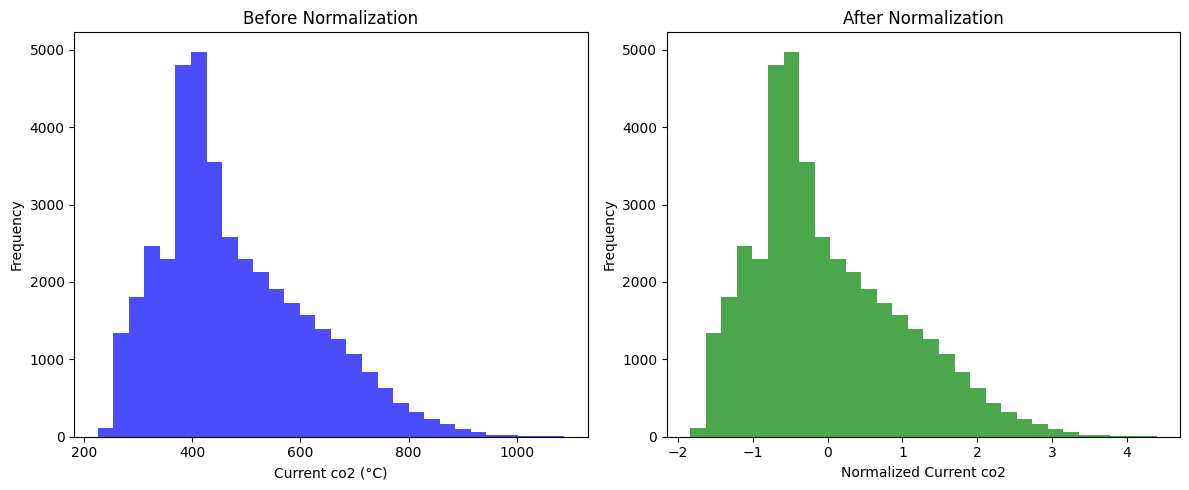

In [9]:
# normalize data
ahu6['current_co2_normalized'] = (ahu6['current_co2'] - ahu6['current_co2'].mean()) / ahu6['current_co2'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['current_co2'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('Current co2 (°C)')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['current_co2_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized Current co2')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\1183918831.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



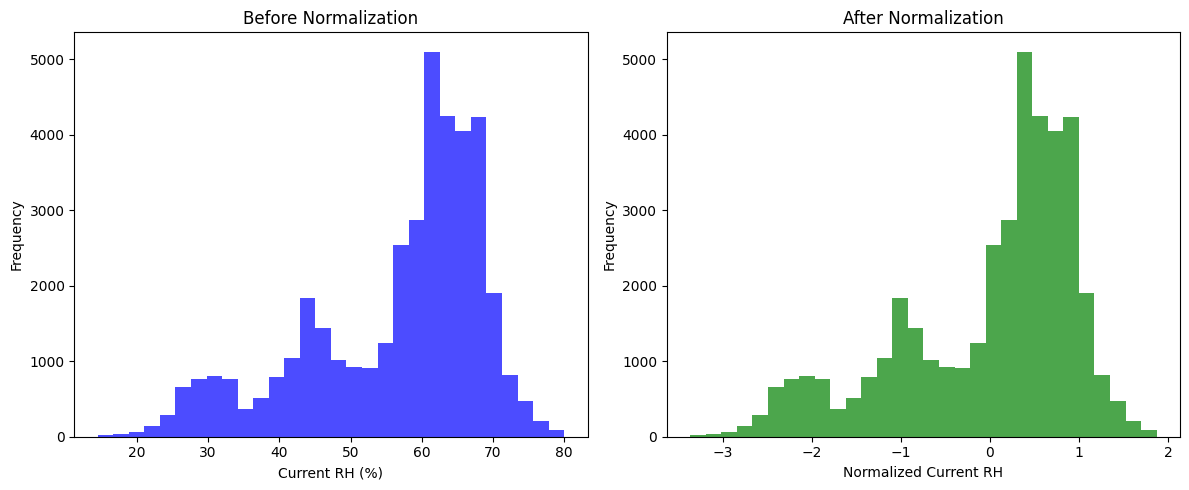

In [10]:
# normalize data
ahu6['current_humidity_normalized'] = (ahu6['current_humidity'] - ahu6['current_humidity'].mean()) / ahu6['current_humidity'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['current_humidity'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('Current RH (%)')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['current_humidity_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized Current RH')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [11]:
ahu6['AHU_OBDM'].fillna(0, inplace=True)

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\1522263355.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\3732539426.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\3732539426.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



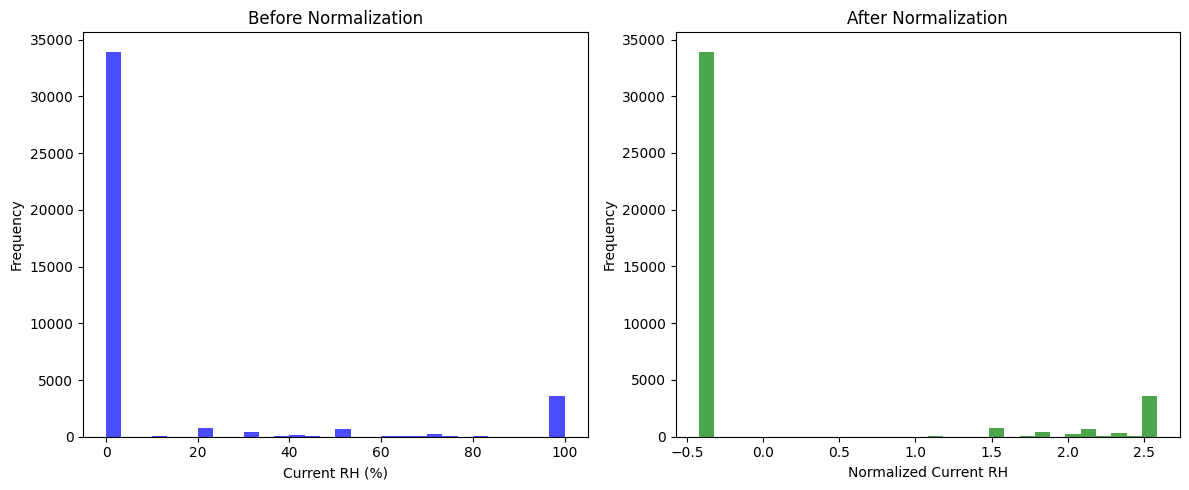

In [12]:
# normalize data
ahu6['AHU_OBDM_log'] = np.log(ahu6['AHU_OBDM'] + 1)  # add 1 to avoid log(0)
ahu6['AHU_OBDM_normalized'] = (ahu6['AHU_OBDM_log'] - ahu6['AHU_OBDM_log'].mean()) / ahu6['AHU_OBDM_log'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['AHU_OBDM'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('Current RH (%)')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['AHU_OBDM_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized Current RH')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\1722035134.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



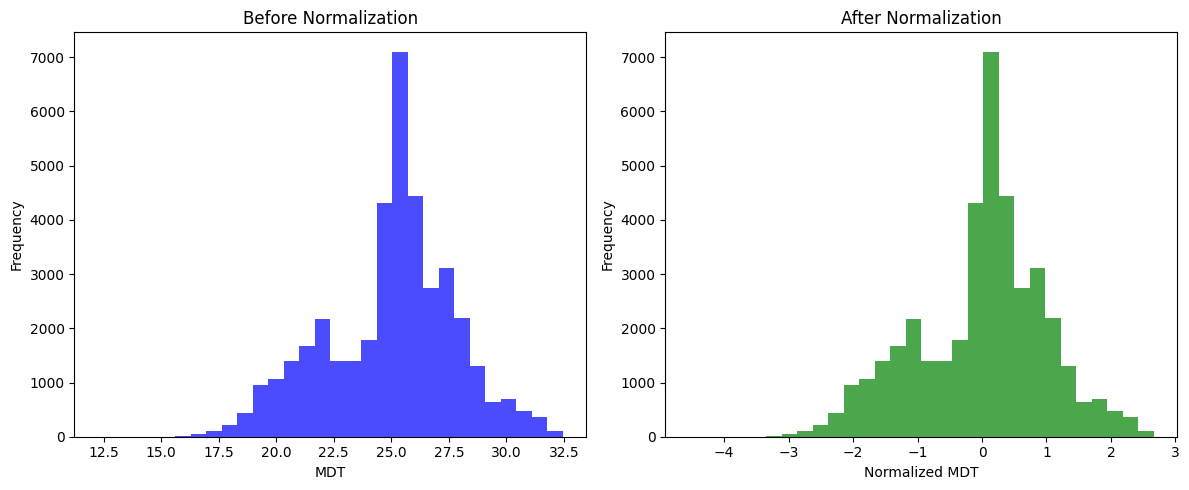

In [13]:
# normalize data
ahu6['mdt_normalized'] = (ahu6['AHU_MDT'] - ahu6['AHU_MDT'].mean()) / ahu6['AHU_MDT'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['AHU_MDT'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('MDT')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['mdt_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized MDT')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\2017208824.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



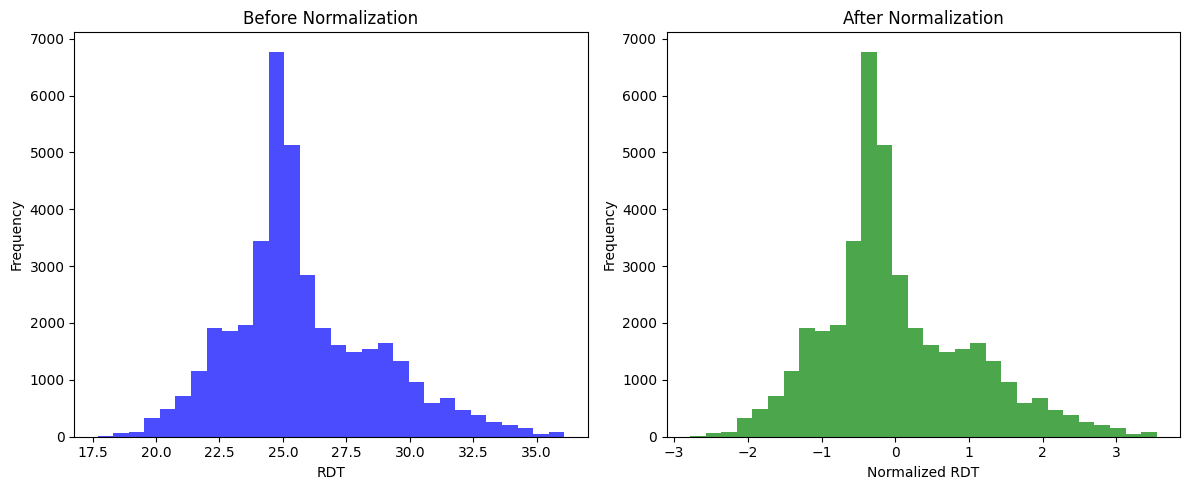

In [14]:
# normalize data
ahu6['RDT_normalized'] = (ahu6['AHU_RDT'] - ahu6['AHU_RDT'].mean()) / ahu6['AHU_RDT'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['AHU_RDT'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('RDT')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['RDT_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized RDT')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\3200403883.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



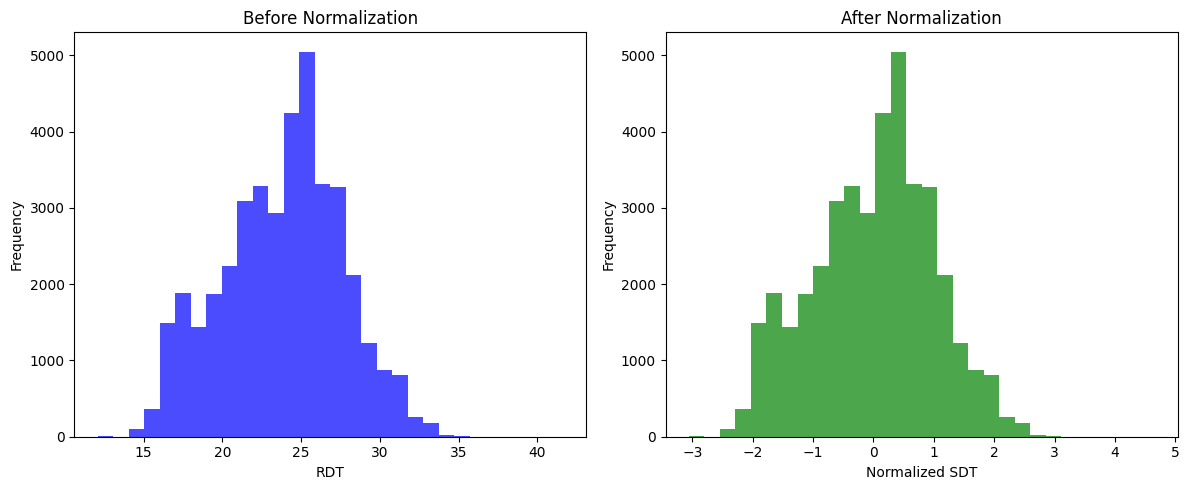

In [15]:
# normalize data
ahu6['SDT_normalized'] = (ahu6['AHU_SDT'] - ahu6['AHU_SDT'].mean()) / ahu6['AHU_SDT'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['AHU_SDT'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('RDT')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['SDT_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized SDT')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\3200403883.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



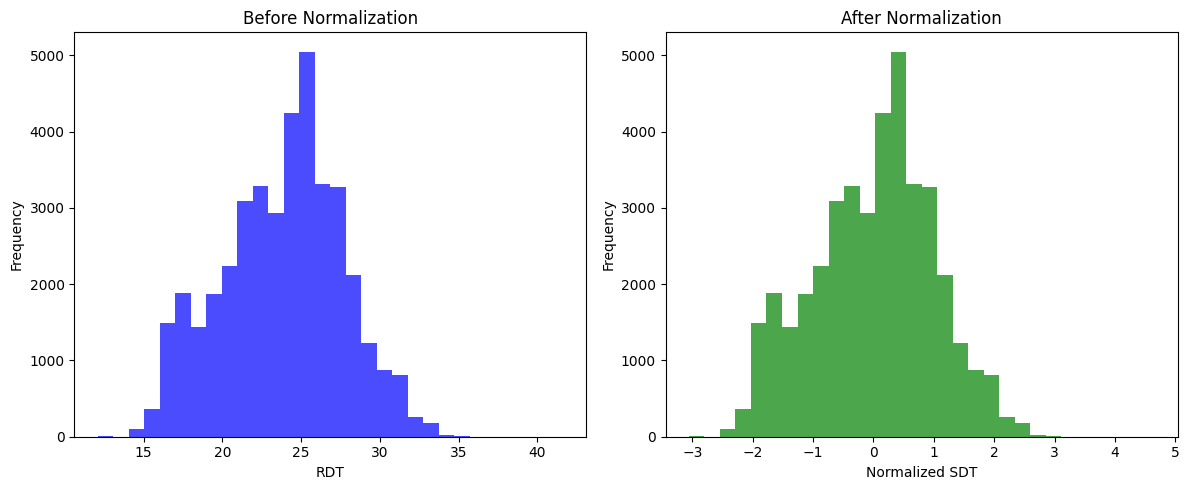

In [16]:
# normalize data
ahu6['SDT_normalized'] = (ahu6['AHU_SDT'] - ahu6['AHU_SDT'].mean()) / ahu6['AHU_SDT'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['AHU_SDT'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('RDT')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['SDT_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized SDT')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [18]:
# new columns with the sum of the FCU values
# FCU_1', 'FCU_2', 'FCU_3', 'FCU_4', 'FCU_5', 'FCU_6', 'FCU_7', 'FCU_8', 'FCU_9', 'FCU_10', 'FCU_11'
# convert active to 1, inactive and NaN to 0
fcu_columns = ['FCU_1', 'FCU_2', 'FCU_3', 'FCU_4', 'FCU_5', 'FCU_6', 'FCU_7', 'FCU_8', 'FCU_9', 'FCU_10', 'FCU_11']
ahu6[fcu_columns] = ahu6[fcu_columns].applymap(lambda x: 1 if x == 'active' else 0)
ahu6['FCU_active_count'] = ahu6[fcu_columns].sum(axis=1)


C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\532324936.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\532324936.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\1709833224.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



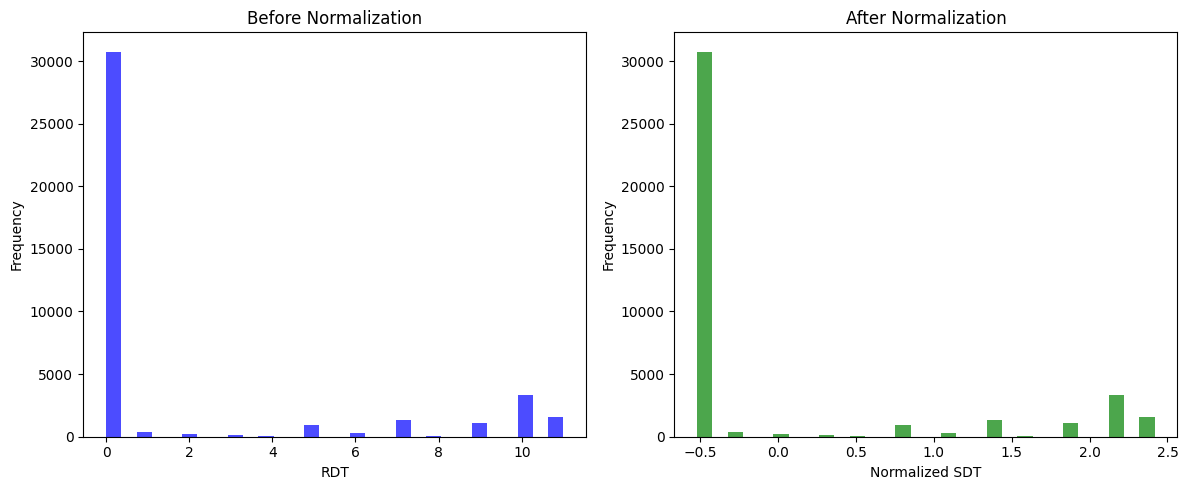

In [21]:
# normalize data
ahu6['FCU_normalized'] = (ahu6['FCU_active_count'] - ahu6['FCU_active_count'].mean()) / ahu6['FCU_active_count'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['FCU_active_count'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('RDT')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['FCU_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized SDT')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\1464014833.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



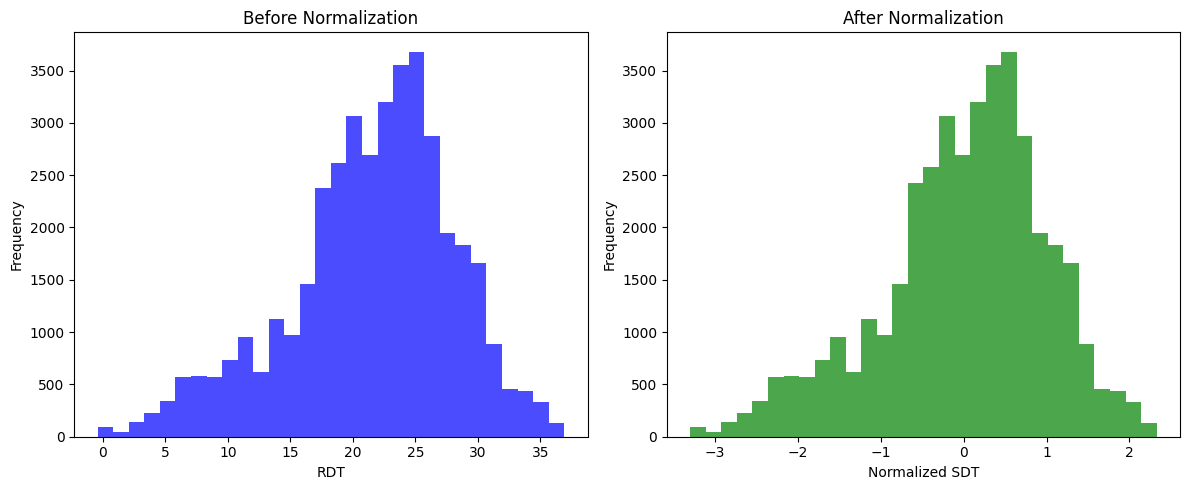

In [22]:
# normalize data
ahu6['temperature_out_normalized'] = (ahu6['temperature_out'] - ahu6['temperature_out'].mean()) / ahu6['temperature_out'].std()

# compare before and after normalization in hist plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(ahu6['temperature_out'], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('RDT')
axs[0].set_ylabel('Frequency')
axs[1].hist(ahu6['temperature_out_normalized'], bins=30, color='green', alpha=0.7)
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Normalized SDT')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of AHU6 Supply to Return Duct Temperature Ratio')

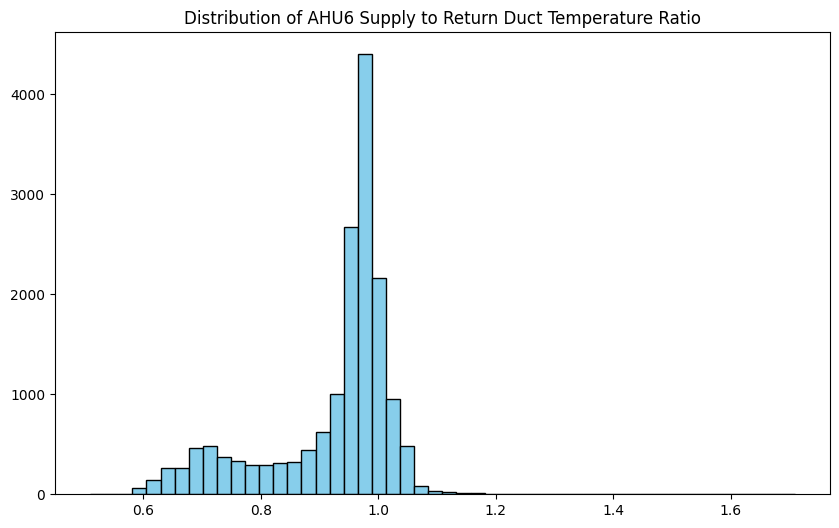

In [17]:
# distribution of the temperature radio sdt over rdt
temps['temp_ratio'] = temps['AHU_SDT'] / temps['AHU_RDT']
plt.figure(figsize=(10,6))
plt.hist(temps['temp_ratio'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of AHU6 Supply to Return Duct Temperature Ratio')

In [82]:
# calculate inertia as the absolute difference between the changes in sdt and rdt in one step
temps['delta_RDT'] = temps['AHU_RDT'].diff().abs()
temps['delta_SDT'] = temps['AHU_SDT'].diff().abs()
temps['inertia'] = (temps['delta_SDT'] - temps['delta_RDT']).abs()

Text(0.5, 0, 'Timestamp')

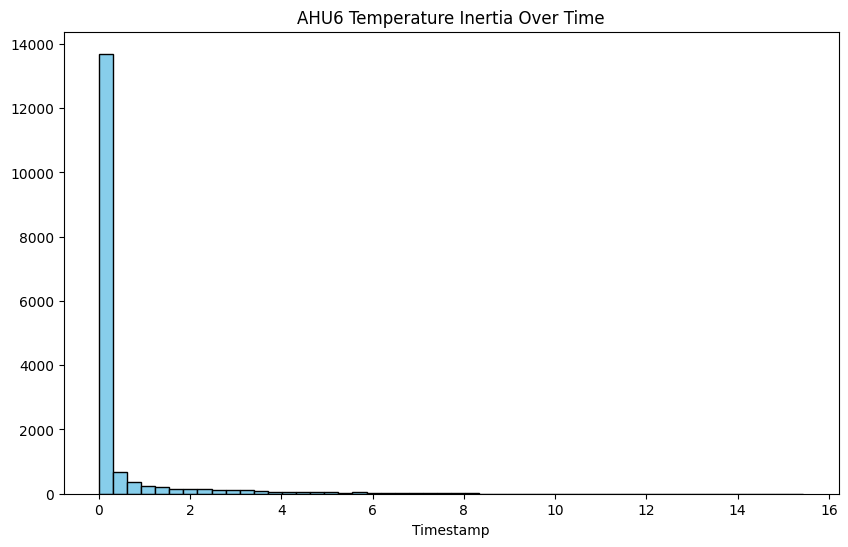

In [83]:
plt.figure(figsize=(10,6))
plt.hist(temps['inertia'], bins=50, color='skyblue', edgecolor='black')
plt.title('AHU6 Temperature Inertia Over Time')
plt.xlabel('Timestamp')

Text(0.5, 0, 'Timestamp')

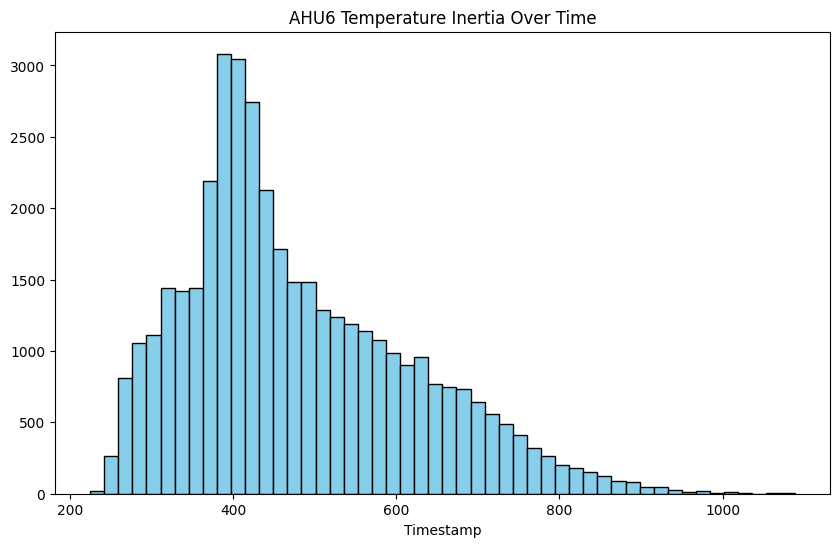

In [13]:
plt.figure(figsize=(10,6))
plt.hist(ahu6['current_co2'], bins=50, color='skyblue', edgecolor='black')
plt.title('AHU6 Temperature Inertia Over Time')
plt.xlabel('Timestamp')

In [27]:
# testing for skewness reduction
before = ahu6['current_co2'].skew()
co2_norm = np.log(ahu6['current_co2'] + 1)
after = co2_norm.skew()
print(f'Skewness before normalization: {before}, after normalization: {after}')

Skewness before normalization: 0.7749616865289349, after normalization: 0.185378269910141


Text(0.5, 0, 'Log Normalized Current co2')

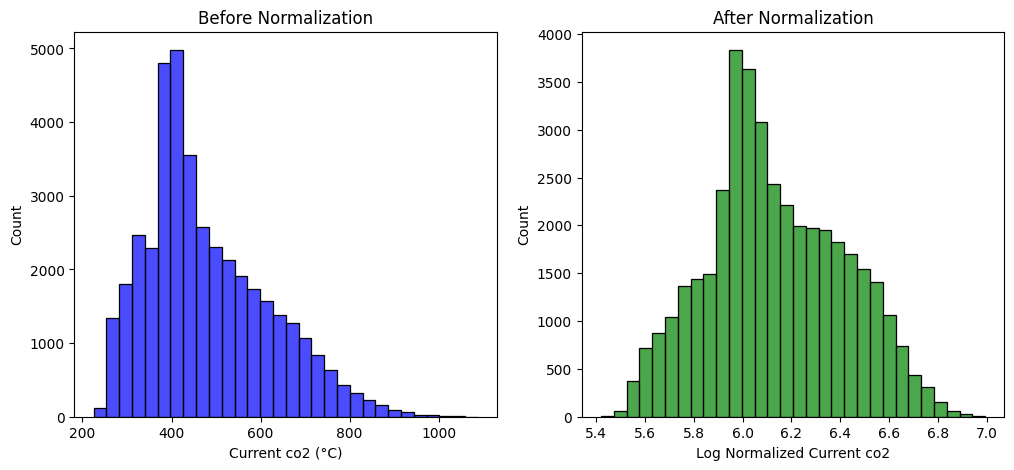

In [29]:
# sns plot of co2 before and after normalization
import seaborn as sns
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(ahu6['current_co2'], bins=30, color='blue', alpha=0.7, ax=axs[0])
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('Current co2 (°C)')
sns.histplot(co2_norm, bins=30, color='green', alpha=0.7, ax=axs[1])
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Log Normalized Current co2')

In [38]:
before = ahu6['current_temperature'].skew()
after = np.log(ahu6['current_temperature']).skew()
before, after

(0.6097017321906937, 0.2541521599547923)

In [104]:
from scipy.stats import boxcox, skew, yeojohnson

before = ahu6['current_humidity'].skew()
#Box-Cox transformation
rh_box_cox = boxcox(ahu6['current_humidity'])
before, skew(rh_box_cox[0]), (ahu6['current_humidity']**3).skew()

(-0.9745478165339279, -0.29077368922943025, -0.2029648455994872)

In [51]:
rh_box_cox

(array([2252.32013579, 1664.8261308 , 2125.73042705, ..., 6104.33678033,
        6602.82638119, 5864.35620012]),
 2.7470971127007835)

Text(0.5, 0, 'Log Normalized Current co2')

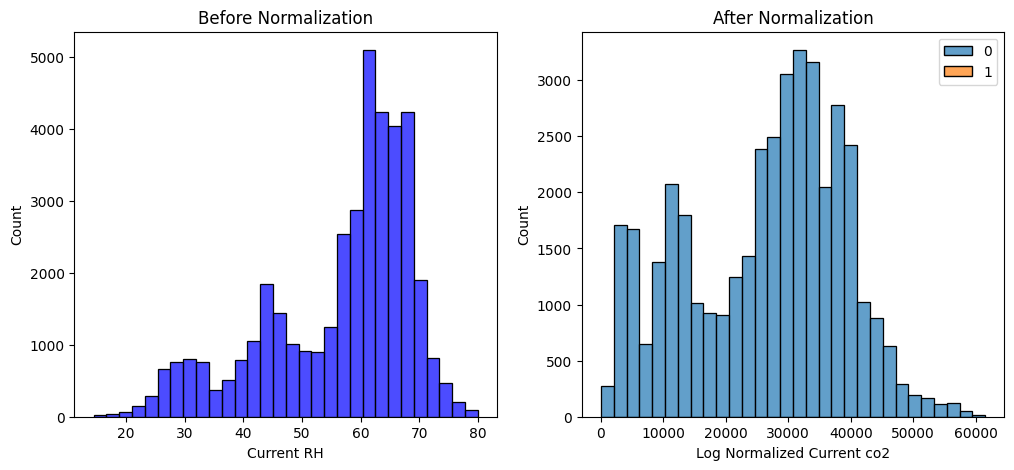

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(ahu6['current_humidity'], bins=30, color='blue', alpha=0.7, ax=axs[0])
axs[0].set_title('Before Normalization')
axs[0].set_xlabel('Current RH')
sns.histplot(rh_box_cox, bins=30, color='green', alpha=0.7, ax=axs[1])
axs[1].set_title('After Normalization')
axs[1].set_xlabel('Log Normalized Current co2')

In [64]:
(ahu6['temperature_out']**1.5).skew()

-0.09110639147272333

<Axes: xlabel='temperature_out', ylabel='Count'>

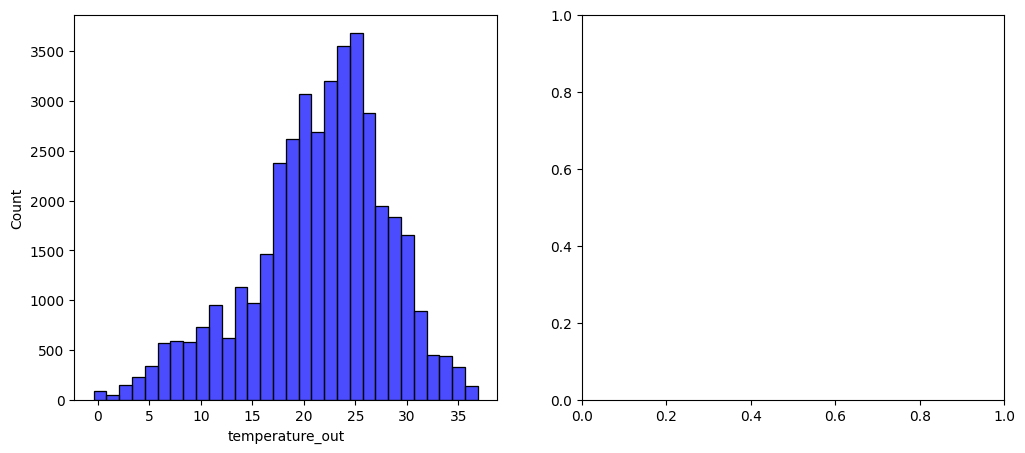

In [60]:
# plot temperature out distribution
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(ahu6['temperature_out'], bins=30, color='blue', alpha=0.7, ax=axs[0])


In [65]:
ahu6['AHU_SDT'].skew()

-0.12353847088250636

In [ ]:
np.log(ahu6['AHU_RDT']).skew()

0.48785043963833213

In [72]:
(ahu6['AHU_MDT']**2).skew()

-0.014143650839818696

In [ ]:
"""Index(['timestamp', 'floor_id', 'hvac_zone', 'current_co2',
       'current_temperature', 'current_humidity', 'floor', 'corner', 'ahu_id',
       'FCU_1', 'FCU_2', 'FCU_3', 'FCU_4', 'FCU_5', 'FCU_6', 'FCU_7', 'FCU_8',
       'FCU_9', 'FCU_10', 'FCU_11', 'AHU_MDM', 'AHU_MDT', 'AHU_MODE',
       'AHU_OBDM', 'AHU_RDT', 'AHU_RUN', 'AHU_SDT', 'AHU_TMSET', 'CHU_SS',
       'CHU_TMSET', 'temperature_out', 'humidity_out', 'solar_radiation'],
      dtype='object')"""

In [ ]:

ahu = ahu6[['timestamp','current_temperature','current_co2','current_humidity',]]



In [106]:
# Summary of transformations and normlalizations, apply standar scaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler

current_temp_scaler = MinMaxScaler()
ahu6['current_temperature_t'] = current_temp_scaler.fit_transform(np.log(ahu6[['current_temperature']]))

current_co2_scaler = MinMaxScaler()
ahu6['current_co2_t'] = current_co2_scaler.fit_transform(np.log(ahu6[['current_co2']]))

ahu6['current_humidity_t'] = (ahu6[['current_humidity']]**3)/1000000

mdt_scaler = MinMaxScaler()
ahu6['AHU_MDT_t'] = mdt_scaler.fit_transform(ahu6[['AHU_MDT']]**2)

rdt_scaler = MinMaxScaler()
ahu6['AHU_RDT_t'] = rdt_scaler.fit_transform(np.log(ahu6[['AHU_RDT']]))

sdt_scaler = MinMaxScaler()
ahu6['AHU_SDT_t'] = sdt_scaler.fit_transform(ahu6[['AHU_SDT']])

out_temp_scaler = MinMaxScaler()
ahu6['temperature_out_t'] = out_temp_scaler.fit_transform((ahu6[['temperature_out']]**1.5))

inertia_scaler = StandardScaler()
ahu6['inertia_t'] = inertia_scaler.fit_transform((temps[['inertia']]**(1/6)).fillna(0))

ratio_scaler = StandardScaler()
ahu6['temp_ratio_t'] = ratio_scaler.fit_transform((temps[['temp_ratio']]**3).fillna(0))

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\650441977.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\650441977.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_29256\650441977.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

ValueError: Length of values (16542) does not match length of index (40177)

In [81]:
(ahu6['current_temperature_t'].skew(),
ahu6['current_co2_t'].skew(),
ahu6['current_humidity_t'].skew(),
ahu6['AHU_MDT_t'].skew(),
ahu6['AHU_RDT_t'].skew(),
ahu6['AHU_SDT_t'].skew(),
ahu6['temperature_out_t'].skew())

(0.2541521599548029,
 0.18409456393043208,
 -0.20296484559948666,
 -0.014143650839820467,
 0.31776793856388197,
 -0.12353847088250379,
 -0.09110639147272291)

In [84]:
temps['temp_ratio'].skew()

-1.1387762403302928

Text(0, 0.5, 'Frequency')

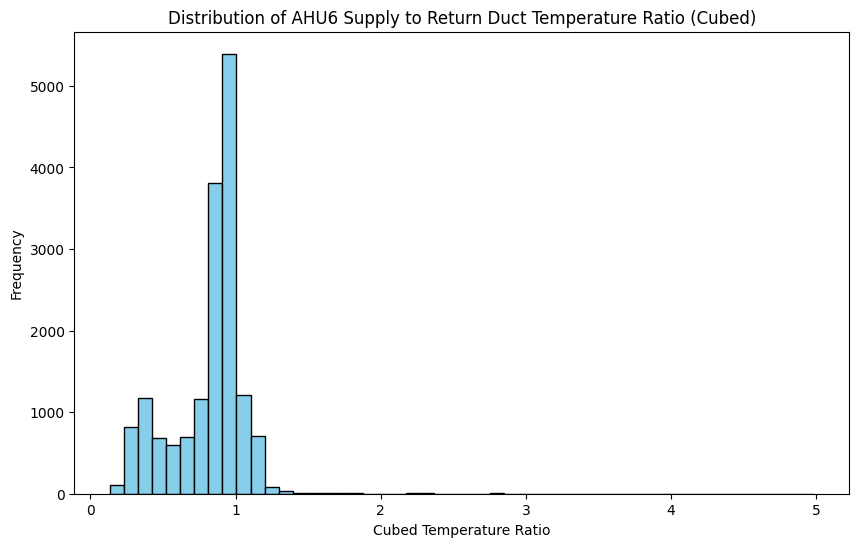

In [89]:
# plot distribution
plt.figure(figsize=(10,6))
plt.hist(temps['temp_ratio']**3, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of AHU6 Supply to Return Duct Temperature Ratio (Cubed)')
plt.xlabel('Cubed Temperature Ratio')
plt.ylabel('Frequency')


In [90]:
temps['inertia'].skew()

4.229576455713535

In [ ]:
skew(yeojohnson((temps['inertia']))[0])

BracketError: The algorithm terminated without finding a valid bracket. Consider trying different initial points.

Text(0, 0.5, 'Frequency')

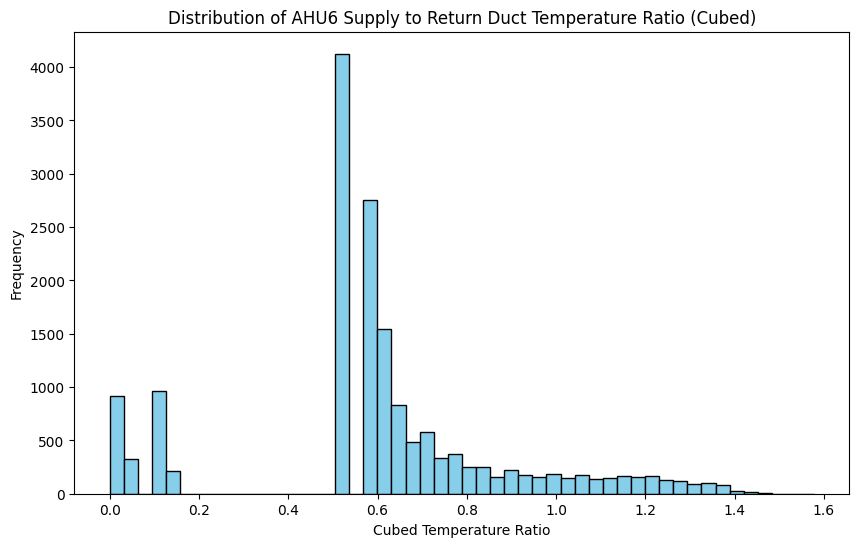

In [98]:
# plot distribution
plt.figure(figsize=(10,6))
plt.hist(((temps['inertia'])**(1/6)), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of AHU6 Supply to Return Duct Temperature Ratio (Cubed)')
plt.xlabel('Cubed Temperature Ratio')
plt.ylabel('Frequency')


Text(0, 0.5, 'Frequency')

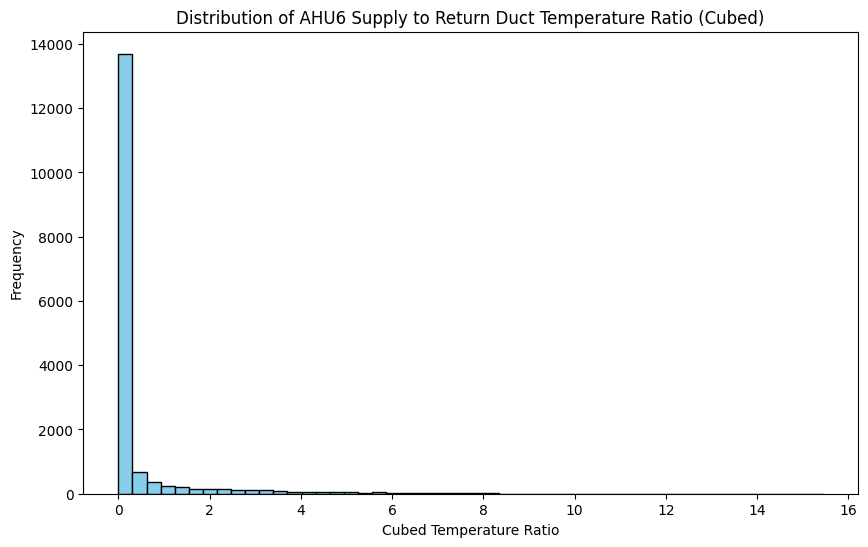

In [99]:
# plot distribution
plt.figure(figsize=(10,6))
plt.hist(((temps['inertia'])), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of AHU6 Supply to Return Duct Temperature Ratio (Cubed)')
plt.xlabel('Cubed Temperature Ratio')
plt.ylabel('Frequency')